# 2D Homogeneous SSR (HYPRE + Profiler)


## Notes Before Running
- Activate local environment: `source setup/activate_optimized_octave.sh`
- In Jupyter, select kernel **Octave (local-rsb)**
- This notebook keeps the original workflow but uses reduced continuation limits for interactive runtime.


In [1]:
%plot -f png -r 600
% Load sparsersb for multithreaded sparse matrix-vector products
pkg load sparsersb;

% Configure toolkit for both GUI and headless Jupyter environments.
try
    graphics_toolkit('qt');
catch
    graphics_toolkit('gnuplot');
end
set(0, 'defaultfigurevisible', 'off');

disp(['Working directory: ', pwd]);
disp(['Graphics toolkit: ', graphics_toolkit()]);


Working directory: /home/beremi/repos/slope_stability/slope_stability


Graphics toolkit: qt


## 1) Main Input Data


In [2]:
% elem_type - type of finite elements; available choices: 'P1', 'P2'
elem_type = 'P2';

% Davis_type - choice of Davis' approach; available choices: 'A', 'B', 'C'
Davis_type = 'B';

% Material parameters:
% [c0, phi, psi, young, poisson, gamma_sat, gamma_unsat]
mat_props = [6, 45, 0, 40000, 0.3, 20, 20];

% Geometrical parameters
x1 = 15;
x3 = 15;
y1 = 10;
y2 = 10;
beta = 45 * pi / 180;
x2 = y2 / tan(beta);

% Mesh parameter
h = 1 / 4;


## 2) Reference Element Data and Mesh Build


In [3]:
% Quadrature points and weights for volume integration
[Xi, WF] = ASSEMBLY.quadrature_volume_2D(elem_type);

% Local basis functions and derivatives
[HatP, DHatP1, DHatP2] = ASSEMBLY.local_basis_volume_2D(elem_type, Xi);

% Mesh creation
switch(elem_type)
    case 'P1'
        [coord, elem, ELEM_ED, EDGE_EL, Q] = MESH.mesh_P1_2D(h, x1, x2, x3, y1, y2);
        disp('P1 elements');
    case 'P2'
        [coord, elem, ELEM_ED, EDGE_EL, Q] = MESH.mesh_P2_2D(h, x1, x2, x3, y1, y2);
        disp('P2 elements');
    otherwise
        error('Bad choice of element type');
end

n_n = size(coord,2);
n_unknown = length(coord(Q));
n_e = size(elem,2);
n_ed = size(EDGE_EL,2);
n_q = length(WF);
n_int = n_e * n_q;

disp(['Mesh data: nodes=', num2str(n_n), ...
      ' unknowns=', num2str(n_unknown), ...
      ' elements=', num2str(n_e), ...
      ' edges=', num2str(n_ed), ...
      ' int_points=', num2str(n_int)]);

% Homogeneous body identifier
material_identifier = zeros(1, n_e);


P2 elements


Mesh data: nodes=42081 unknowns=83280 elements=20800 edges=31440 int_points=145600


### Mesh Preview


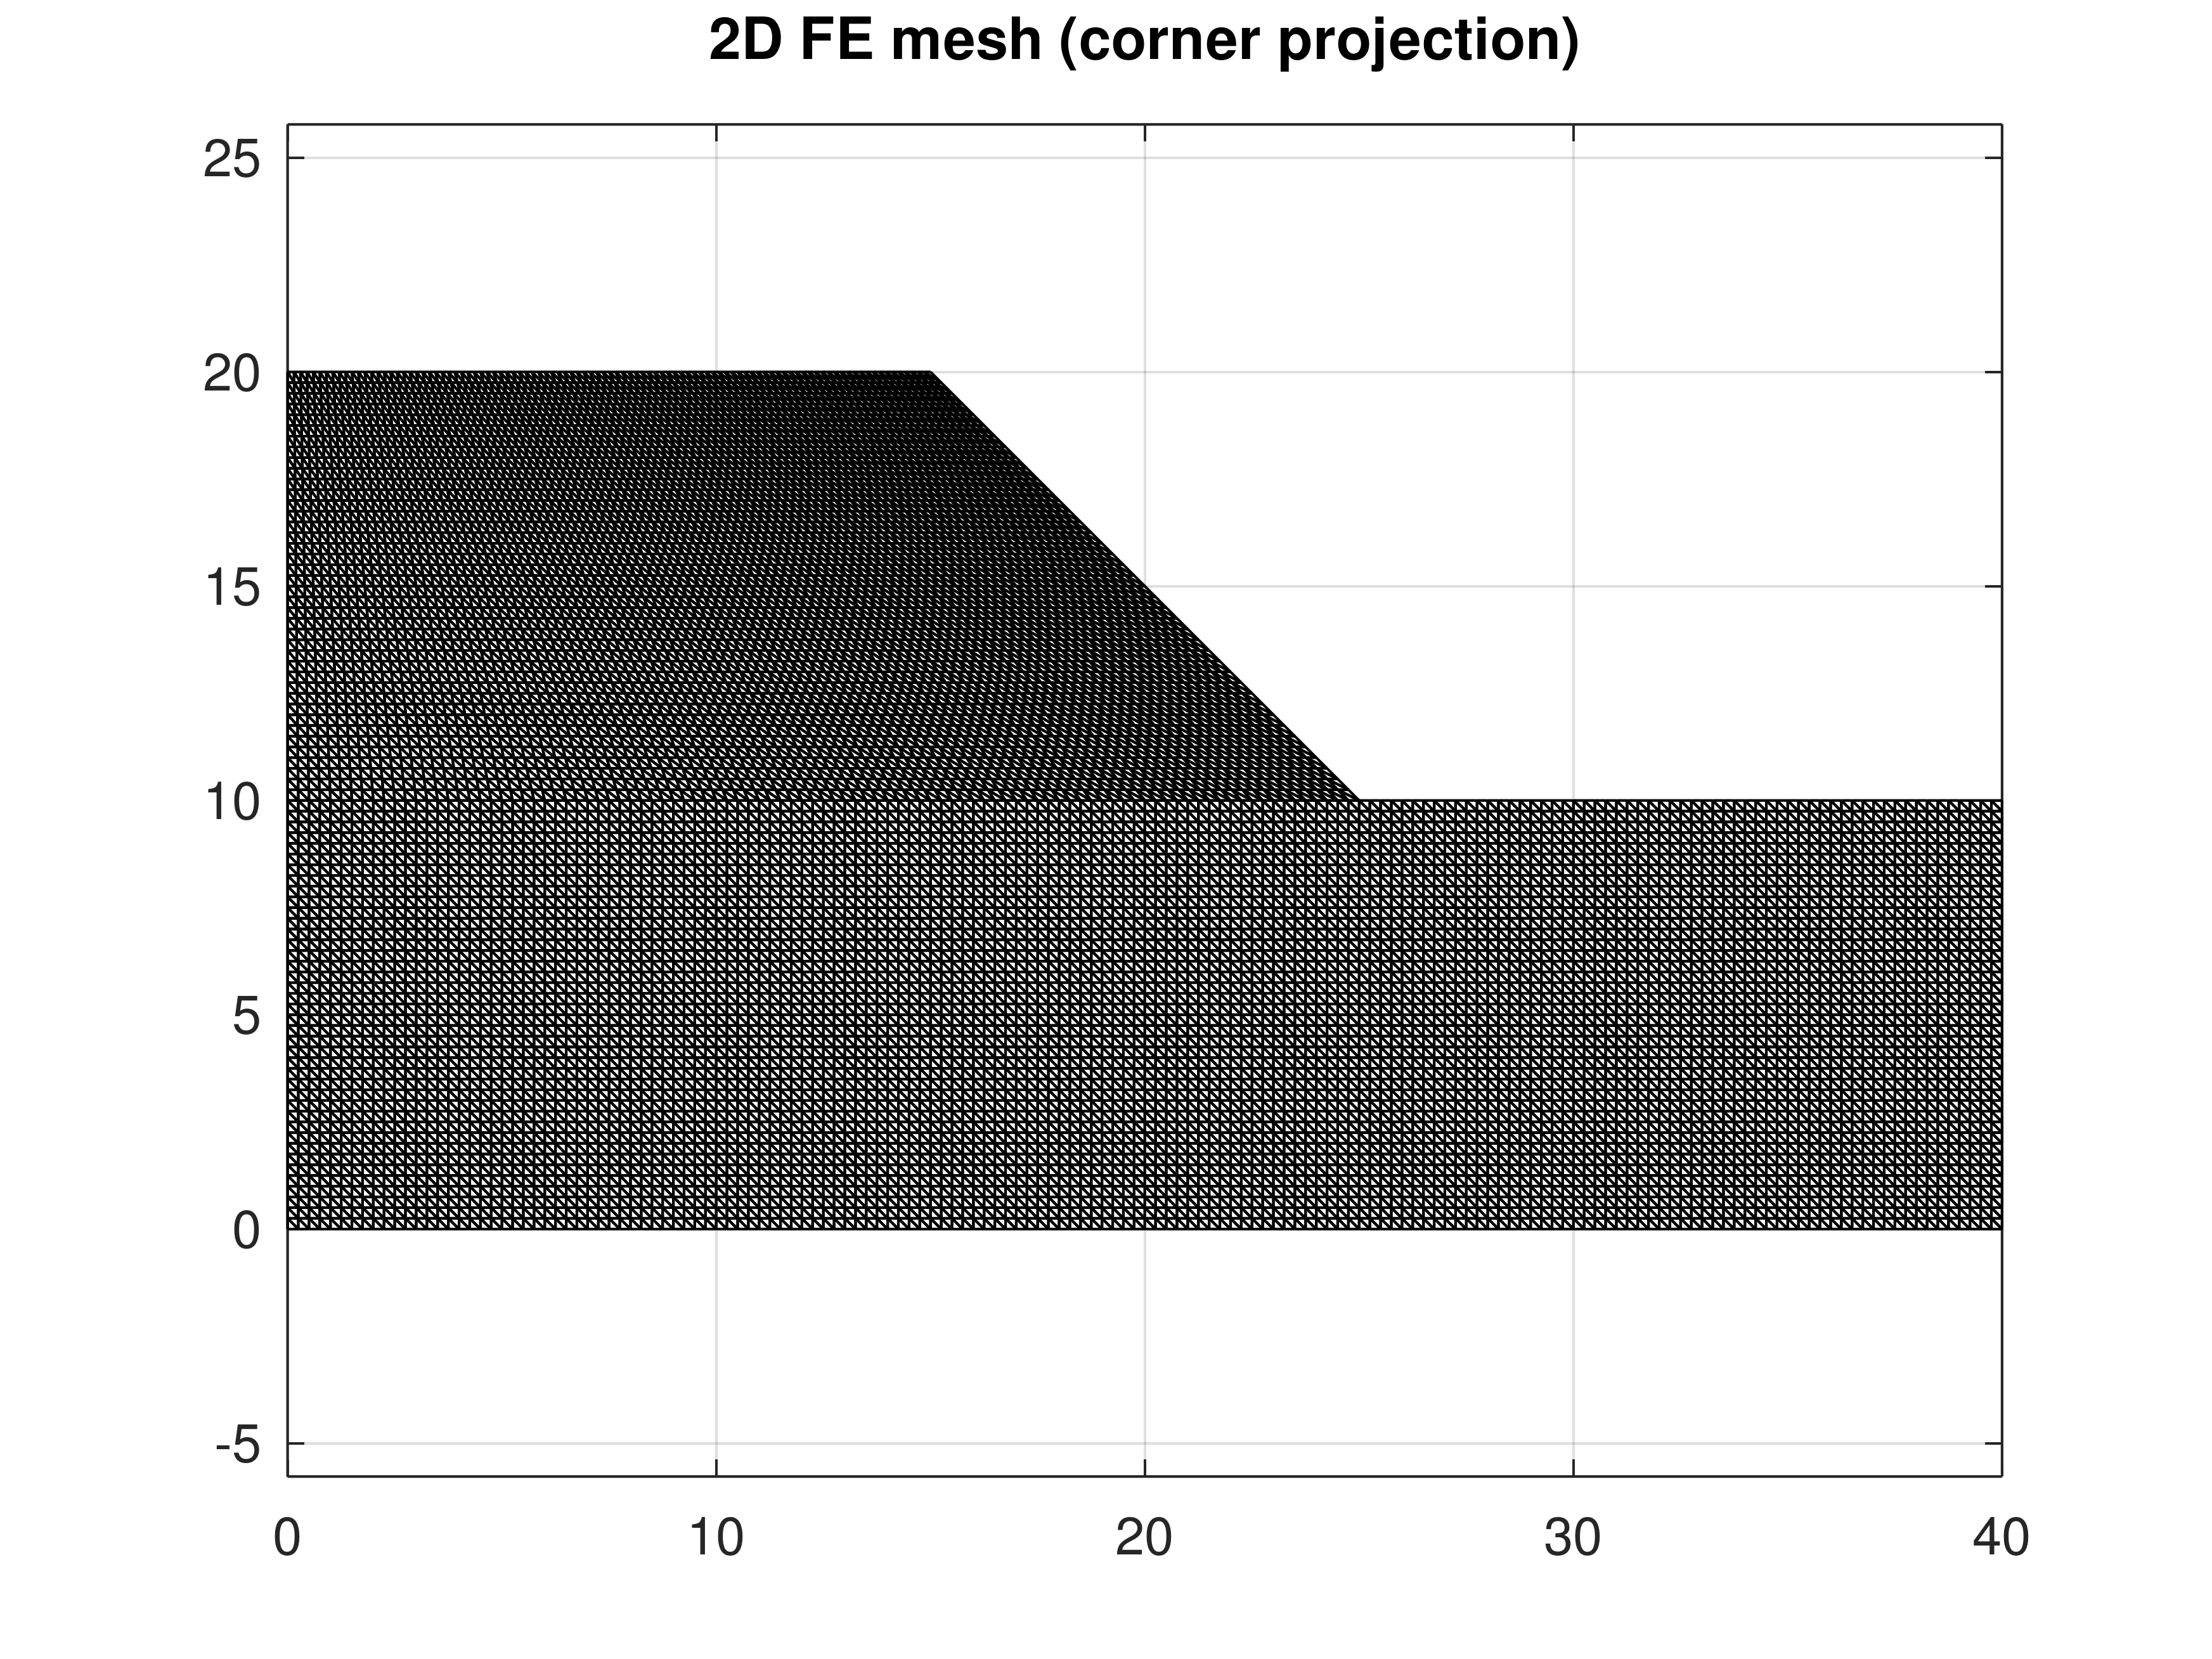

In [4]:
% Plot P1 corner-triangle projection for quick visual check.
tri = elem(1:3, :)';
figure;
triplot(tri, coord(1,:), coord(2,:), 'k-');
axis equal; grid on;
title('2D FE mesh (corner projection)');


## 3) Mechanical Material Fields and Assembly


In [5]:
fields = {'c0', 'phi', 'psi', 'young', 'poisson', 'gamma_sat', 'gamma_unsat'};
materials = cellfun(@(x) cell2struct(num2cell(x), fields, 2), num2cell(mat_props, 2), 'UniformOutput', false);

% Homogeneous benchmark: fully saturated body.
saturation = true(1, n_int);

[c0, phi, psi, shear, bulk, lame, gamma] = ...
    ASSEMBLY.heterogenous_materials(material_identifier, saturation, n_q, materials);

[K_elast, B, WEIGHT, DPhi1_out, DPhi2_out] = ASSEMBLY.elastic_stiffness_matrix_2D( ...
    elem, coord, DHatP1, DHatP2, WF, shear, lame);

f_V_int = [zeros(1, n_int); -gamma];
f_V = ASSEMBLY.vector_volume_2D(elem, coord, f_V_int, HatP, WEIGHT);


## 4) Continuation, Newton, and Linear Solver Parameters


In [6]:
% Continuation parameters
lambda_init = 0.9;
d_lambda_init = 0.05;
d_lambda_min = 1e-5;
d_lambda_diff_scaled_min = 0.001;
omega_max_stop = 5e3;    % Reduced for notebook runtime (script uses 7e7)
step_max = 100;            % Reduced for notebook runtime (script uses 100)

% Newton parameters
it_newt_max = 30;
it_damp_max = 10;
tol = 1e-4;
r_min = 1e-4;

% Linear solver settings (HYPRE BoomerAMG + DFGMRES)
% agmg folder is baked into LINEAR_SOLVERS.set_linear_solver
solver_type = 'DFGMRES_HYPRE_BOOMERAMG';

linear_solver_tolerance = 1e-1;
linear_solver_maxit = 100;
deflation_basis_tolerance = 1e-3;
linear_solver_printing = 0;

boomeramg_opts = struct('threads', 16, 'print_level', 0, ...
    'use_as_preconditioner', true);

linear_system_solver = LINEAR_SOLVERS.set_linear_solver(solver_type, ...
    linear_solver_tolerance, linear_solver_maxit, deflation_basis_tolerance, ...
    linear_solver_printing, Q, coord, boomeramg_opts);

% Constitutive model object
n_strain = 3;
constitutive_matrix_builder = CONSTITUTIVE_PROBLEM.CONSTITUTIVE(...
    B, c0, phi, psi, Davis_type, shear, bulk, lame, WEIGHT, n_strain, n_int, 2);

% Enable element-level tangent assembly path for 2D B'*D*B values.
constitutive_matrix_builder.set_element_data(elem, DPhi1_out, DPhi2_out);
disp(['2D element-level tangent mex enabled = ', num2str(constitutive_matrix_builder.elem_use_mex)]);
disp(['2D constitutive mex enabled = ', num2str(constitutive_matrix_builder.use_2D_mex)]);

% Shared profiler
profiler = PROFILING.Profiler();
constitutive_matrix_builder.profiler = profiler;
linear_system_solver.profiler = profiler;


Element data set: n_p=6, n_e=20800, n_q=7, mex=1


2D element-level tangent mex enabled = 1

2D constitutive mex enabled = 1


## 5) Run SSR Continuation


In [7]:
direct_on = 1;
indirect_on = 1;

if direct_on
    disp('Direct continuation method');
    tic;
    [U2, lambda_hist2, omega_hist2, Umax_hist2] = CONTINUATION.SSR_direct_continuation(...
        lambda_init, d_lambda_init, d_lambda_min, d_lambda_diff_scaled_min, step_max, ...
        it_newt_max, it_damp_max, tol, r_min, K_elast, Q, f_V, ...
        constitutive_matrix_builder, linear_system_solver.copy());
    time_run_direct = toc;
    disp(['Running_time_direct = ', num2str(time_run_direct)]);
end

if indirect_on
    disp('Indirect continuation method');
    tic;
    [U3, lambda_hist3, omega_hist3, Umax_hist3, stats] = CONTINUATION.SSR_indirect_continuation(...
        lambda_init, d_lambda_init, d_lambda_min, d_lambda_diff_scaled_min, step_max, ...
        omega_max_stop, it_newt_max, it_damp_max, tol, r_min, K_elast, Q, f_V, ...
        constitutive_matrix_builder, linear_system_solver.copy());
    time_run_indirect = toc;
    disp(['Running_time_indirect = ', num2str(time_run_indirect)]);
end

if ~isempty(strfind(upper(char(solver_type)), 'BOOMERAMG'))
    LINEAR_SOLVERS.hypre_boomeramg_clear();
end


Direct continuation method


Init step 1: lambda=0.9


Initialising K_r(Q,Q) sparse pattern ... done  (1.2 s, n_Q = 83280, nnz = 1895724)


Building element scatter map ... done  (0.7 s, n_local_dof=12, map_size=24 MB)

  newton it=1  rel_resid=1.00e+00  alpha=1.00  r=0.0001  lin_it=6  step_time=0.14 s

...

  newton_ind_SSR it=25  rel_resid=2.70e-04  alpha=1.00  r=0.0001  lin_it=[W:0,V:37]  step_time=0.46 s

  newton_ind_SSR it=26  rel_resid=2.55e-04  alpha=1.00  r=0.0001  lin_it=[W:0,V:37]  step_time=0.44 s

  newton_ind_SSR it=27  rel_resid=2.42e-04  alpha=1.00  r=0.0001  lin_it=[W:0,V:37]  step_time=0.46 s

  newton_ind_SSR it=28  rel_resid=2.32e-04  alpha=1.00  r=0.0001  lin_it=[W:0,V:37]  step_time=0.45 s

newton_ind_SSR summary: status=max_iterations, it=30, rel_resid=2.137088e-04, lin_it_total=[W:3,V:964], wall_time=12.88 s
  accepted: lambda=1.16411, d_lambda=0.000447473, d_lambda_diff_scaled=0.000905433, omega=487.325, d_omega=30.6866, U_max=1.82113
Stop: minimal increase of lambda achieved.
Running_time_indirect = 60.0963


## Profiler Summary


In [8]:
profiler.print_summary();



  Profiler Summary
  Time      %       Calls  Operation
  --------- ------ ------  ------------------------------
     92.60s  56.0%   1138  DFGMRES.solve
     23.09s  14.0%    925  DFGMRES.update_preconditioner
     11.99s   7.2%    973  DFGMRES.A_orthogonalize
     11.46s   6.9%   2666  CONSTITUTIVE.build_F
      8.93s   5.4%   1669  CONSTITUTIVE.stress
      6.79s   4.1%    577  CONSTITUTIVE.reduction
      5.81s   3.5%    997  CONSTITUTIVE.stress_tangent
      2.58s   1.6%    973  CONSTITUTIVE.build_K_tangent_QQ_vals
      1.21s   0.7%     48  DFGMRES.setup_preconditioner
      0.69s   0.4%   1146  DFGMRES.expand_deflation_basis
      0.34s   0.2%     23  CONSTITUTIVE.potential
  --------- ------ ------  ------------------------------
    165.49s                TOTAL

  Sub-profile: DFGMRES.solve  (92.60s total, 1138 calls)
  --------- ------ ------  ------------------------------
     40.53s  43.8%   1039  precond_apply
     18.17s  19.6%   1039  deflation_project
     15.01s  16

## 6) Mechanical Results and Convergence



    __axis_label__ at line 38 column 6


    xlabel at line 59 column 3


    plot_convergence at line 353 column 17


    __axis_label__ at line 38 column 6


    ylabel at line 61 column 3


    plot_convergence at line 354 column 17

Final lambda direct   = 1.16406250
Final lambda indirect = 1.16411213
Relative direct/indirect gap = 4.2639e-05


Monotonicity check (indirect): lambda=1, omega=1


Notebook workflow completed.


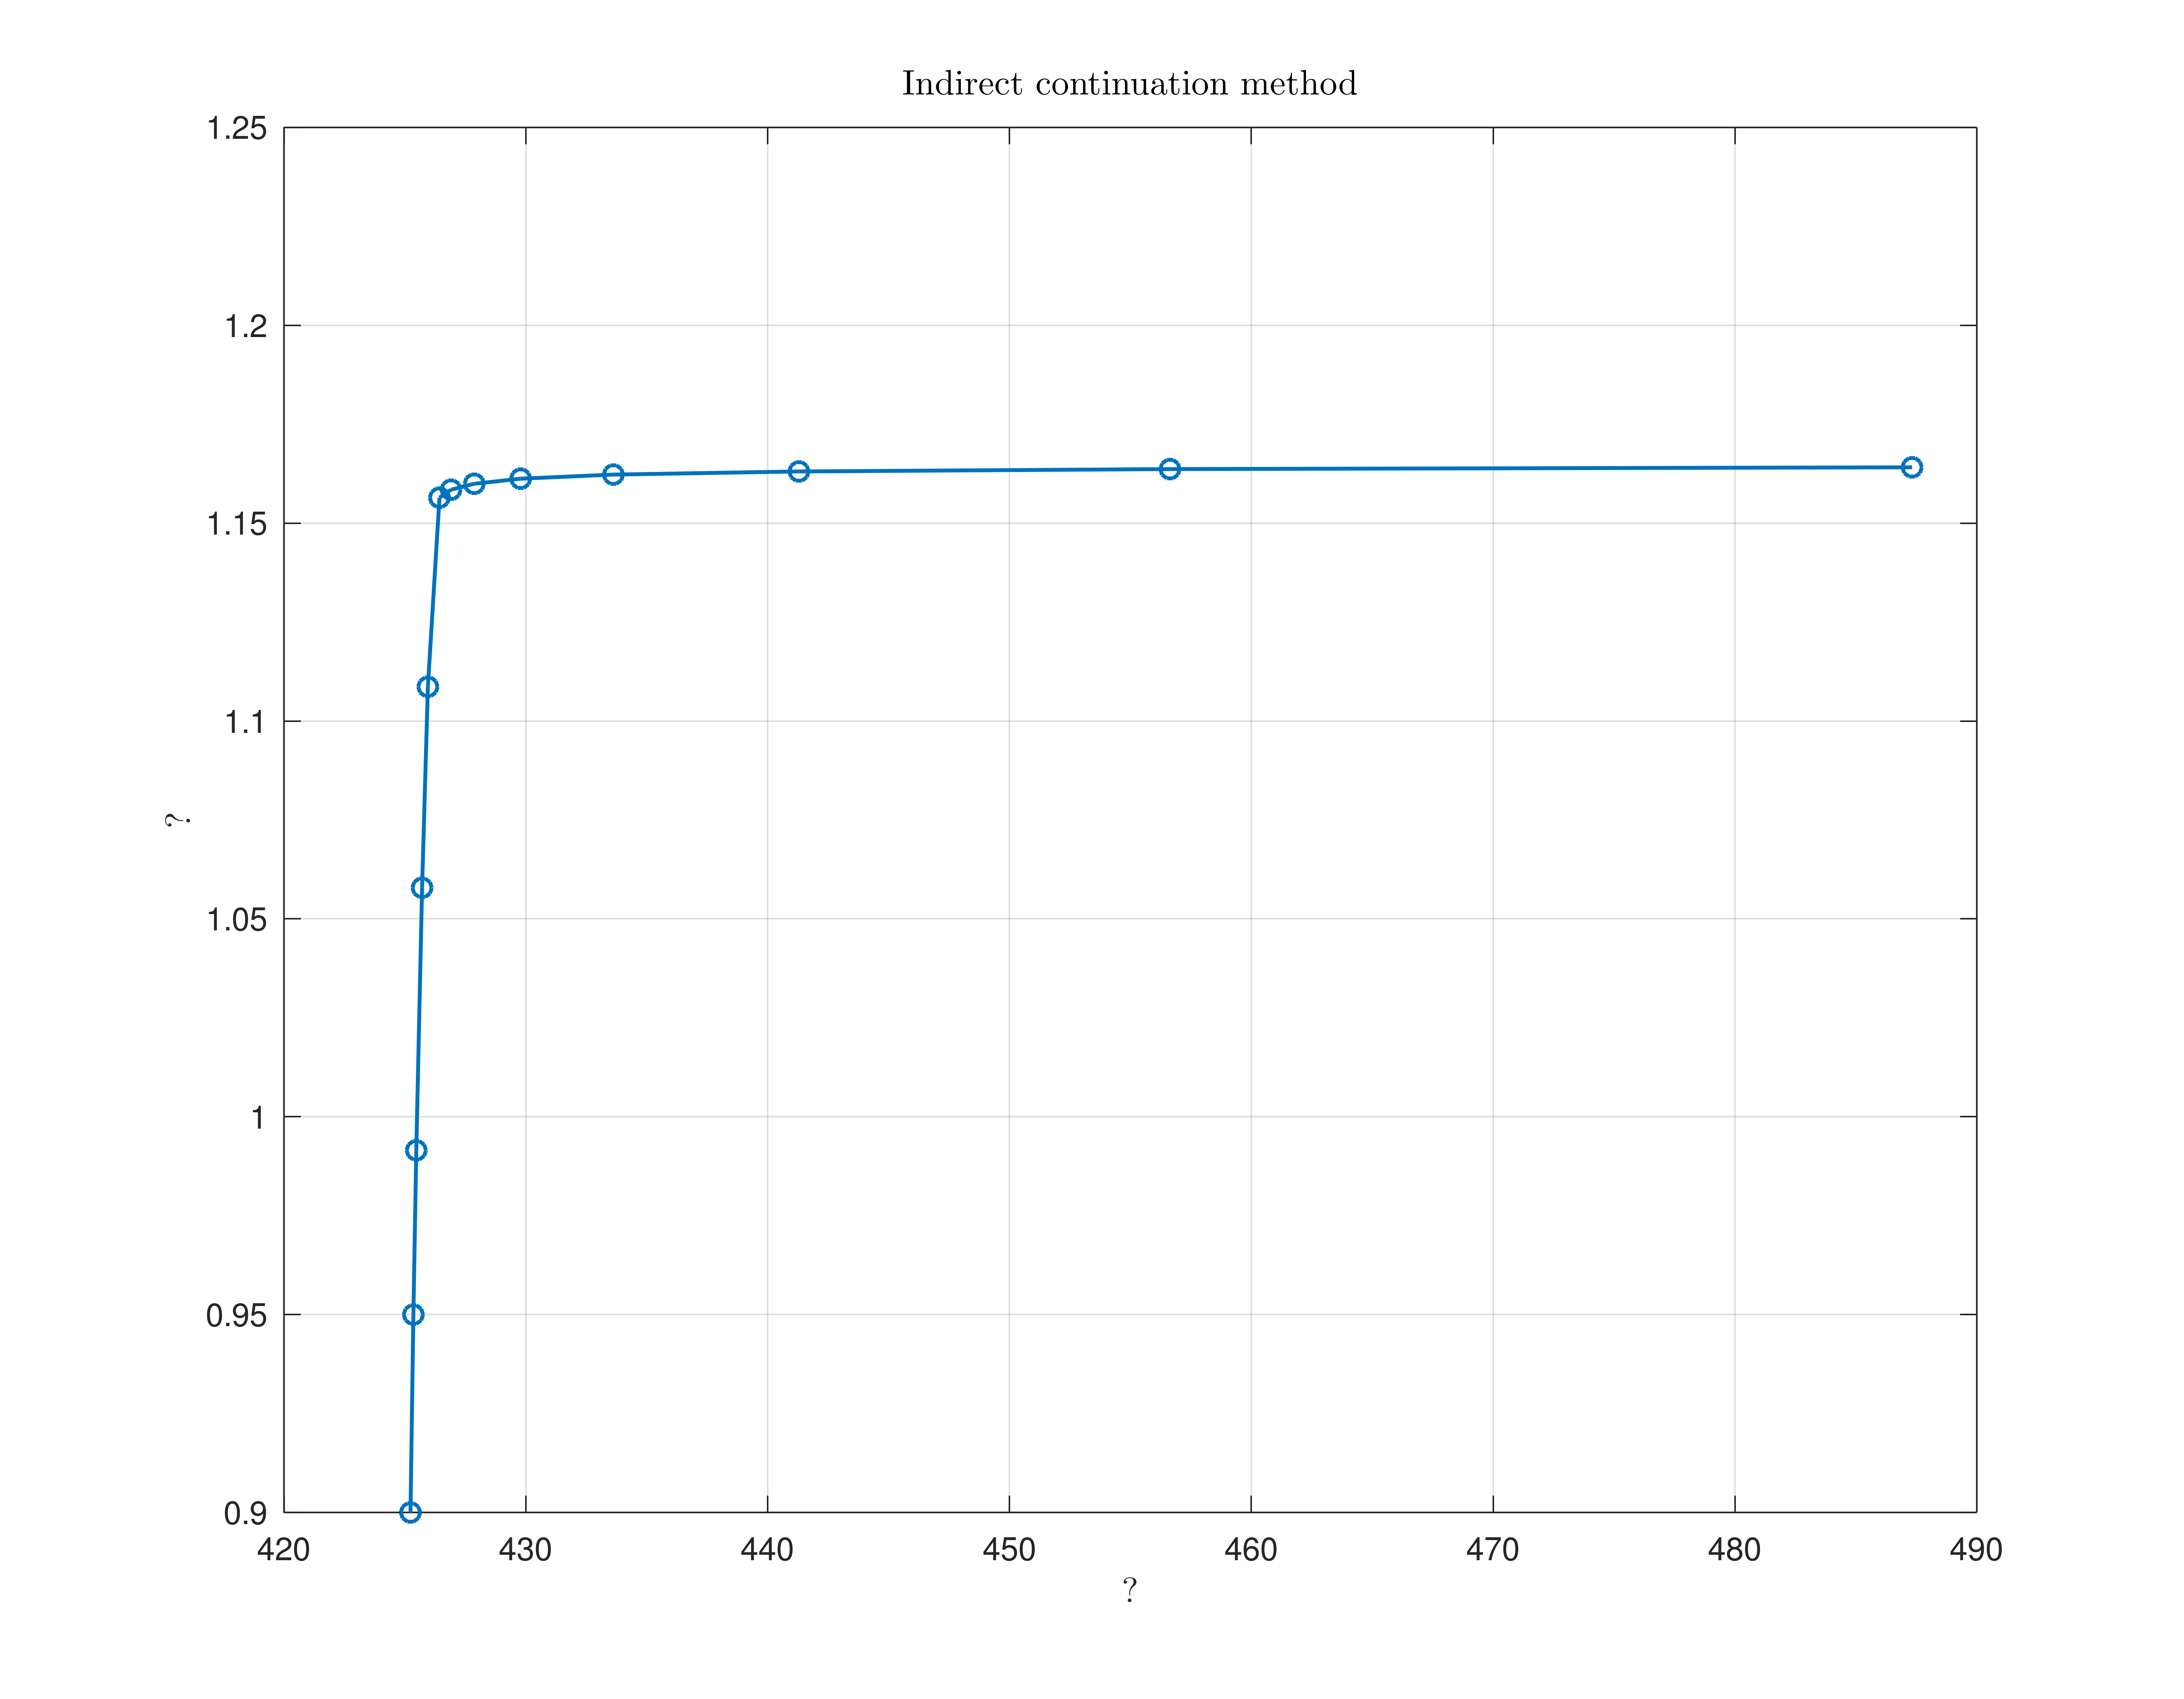

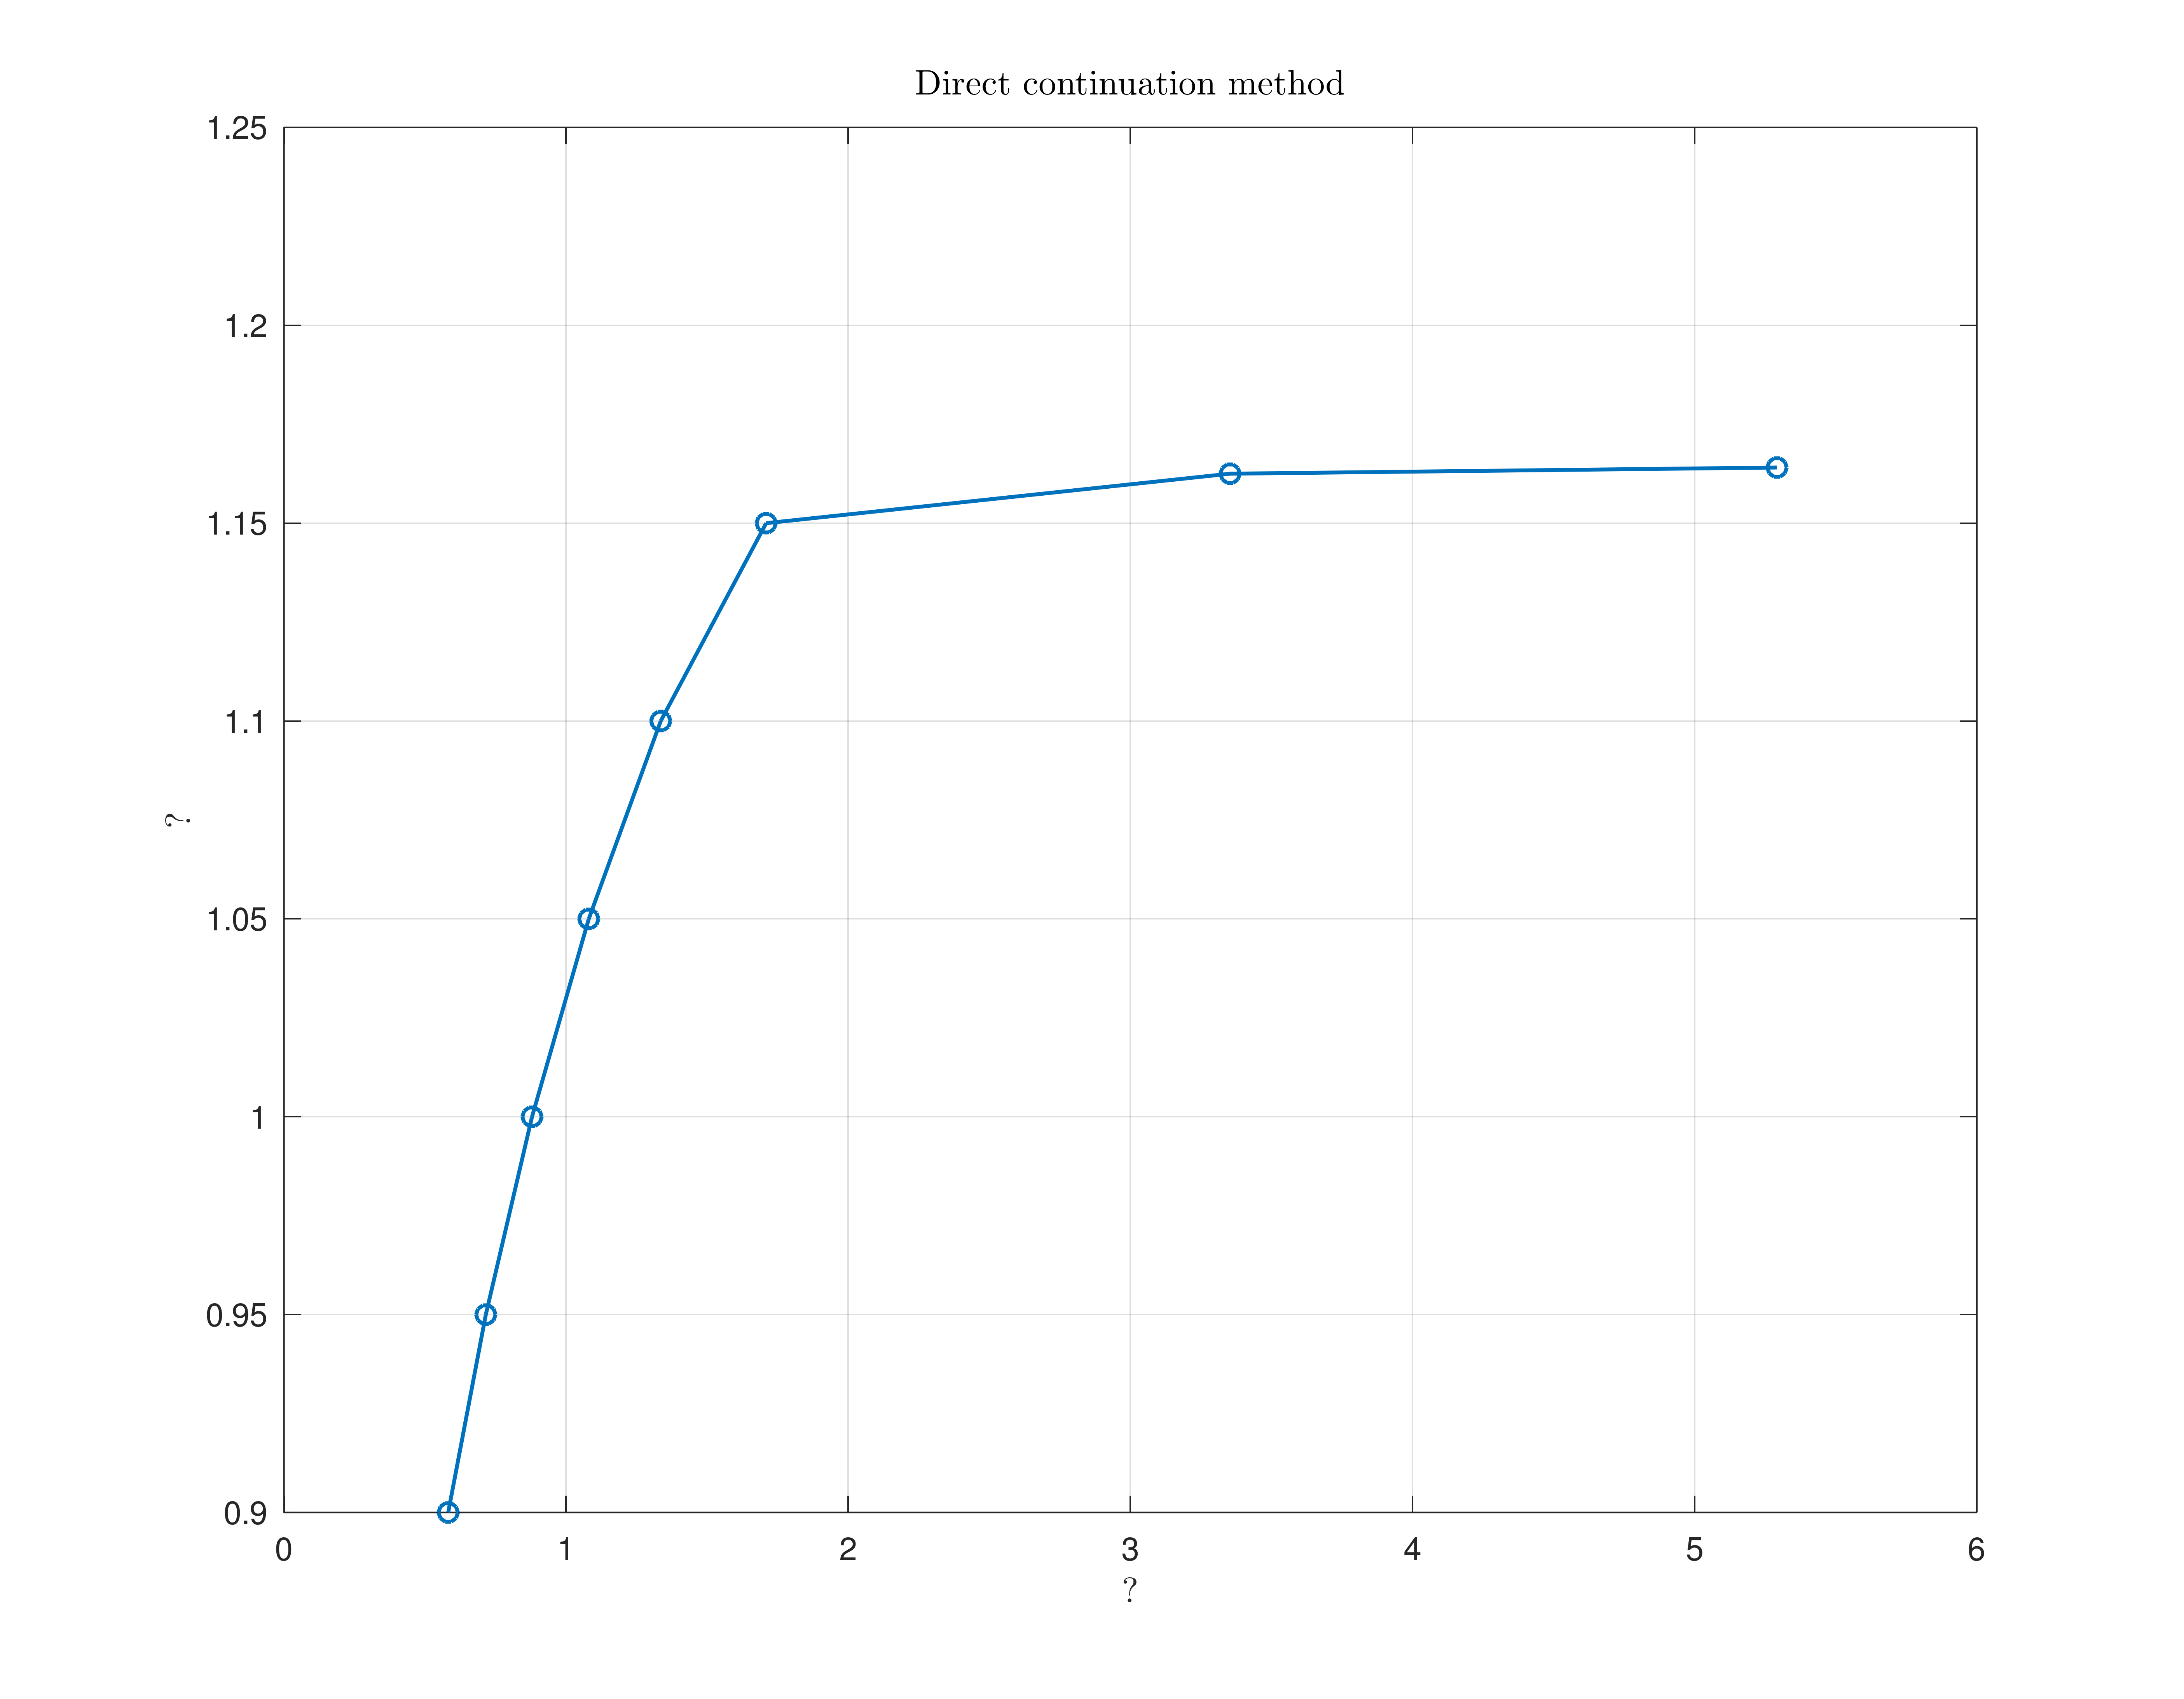

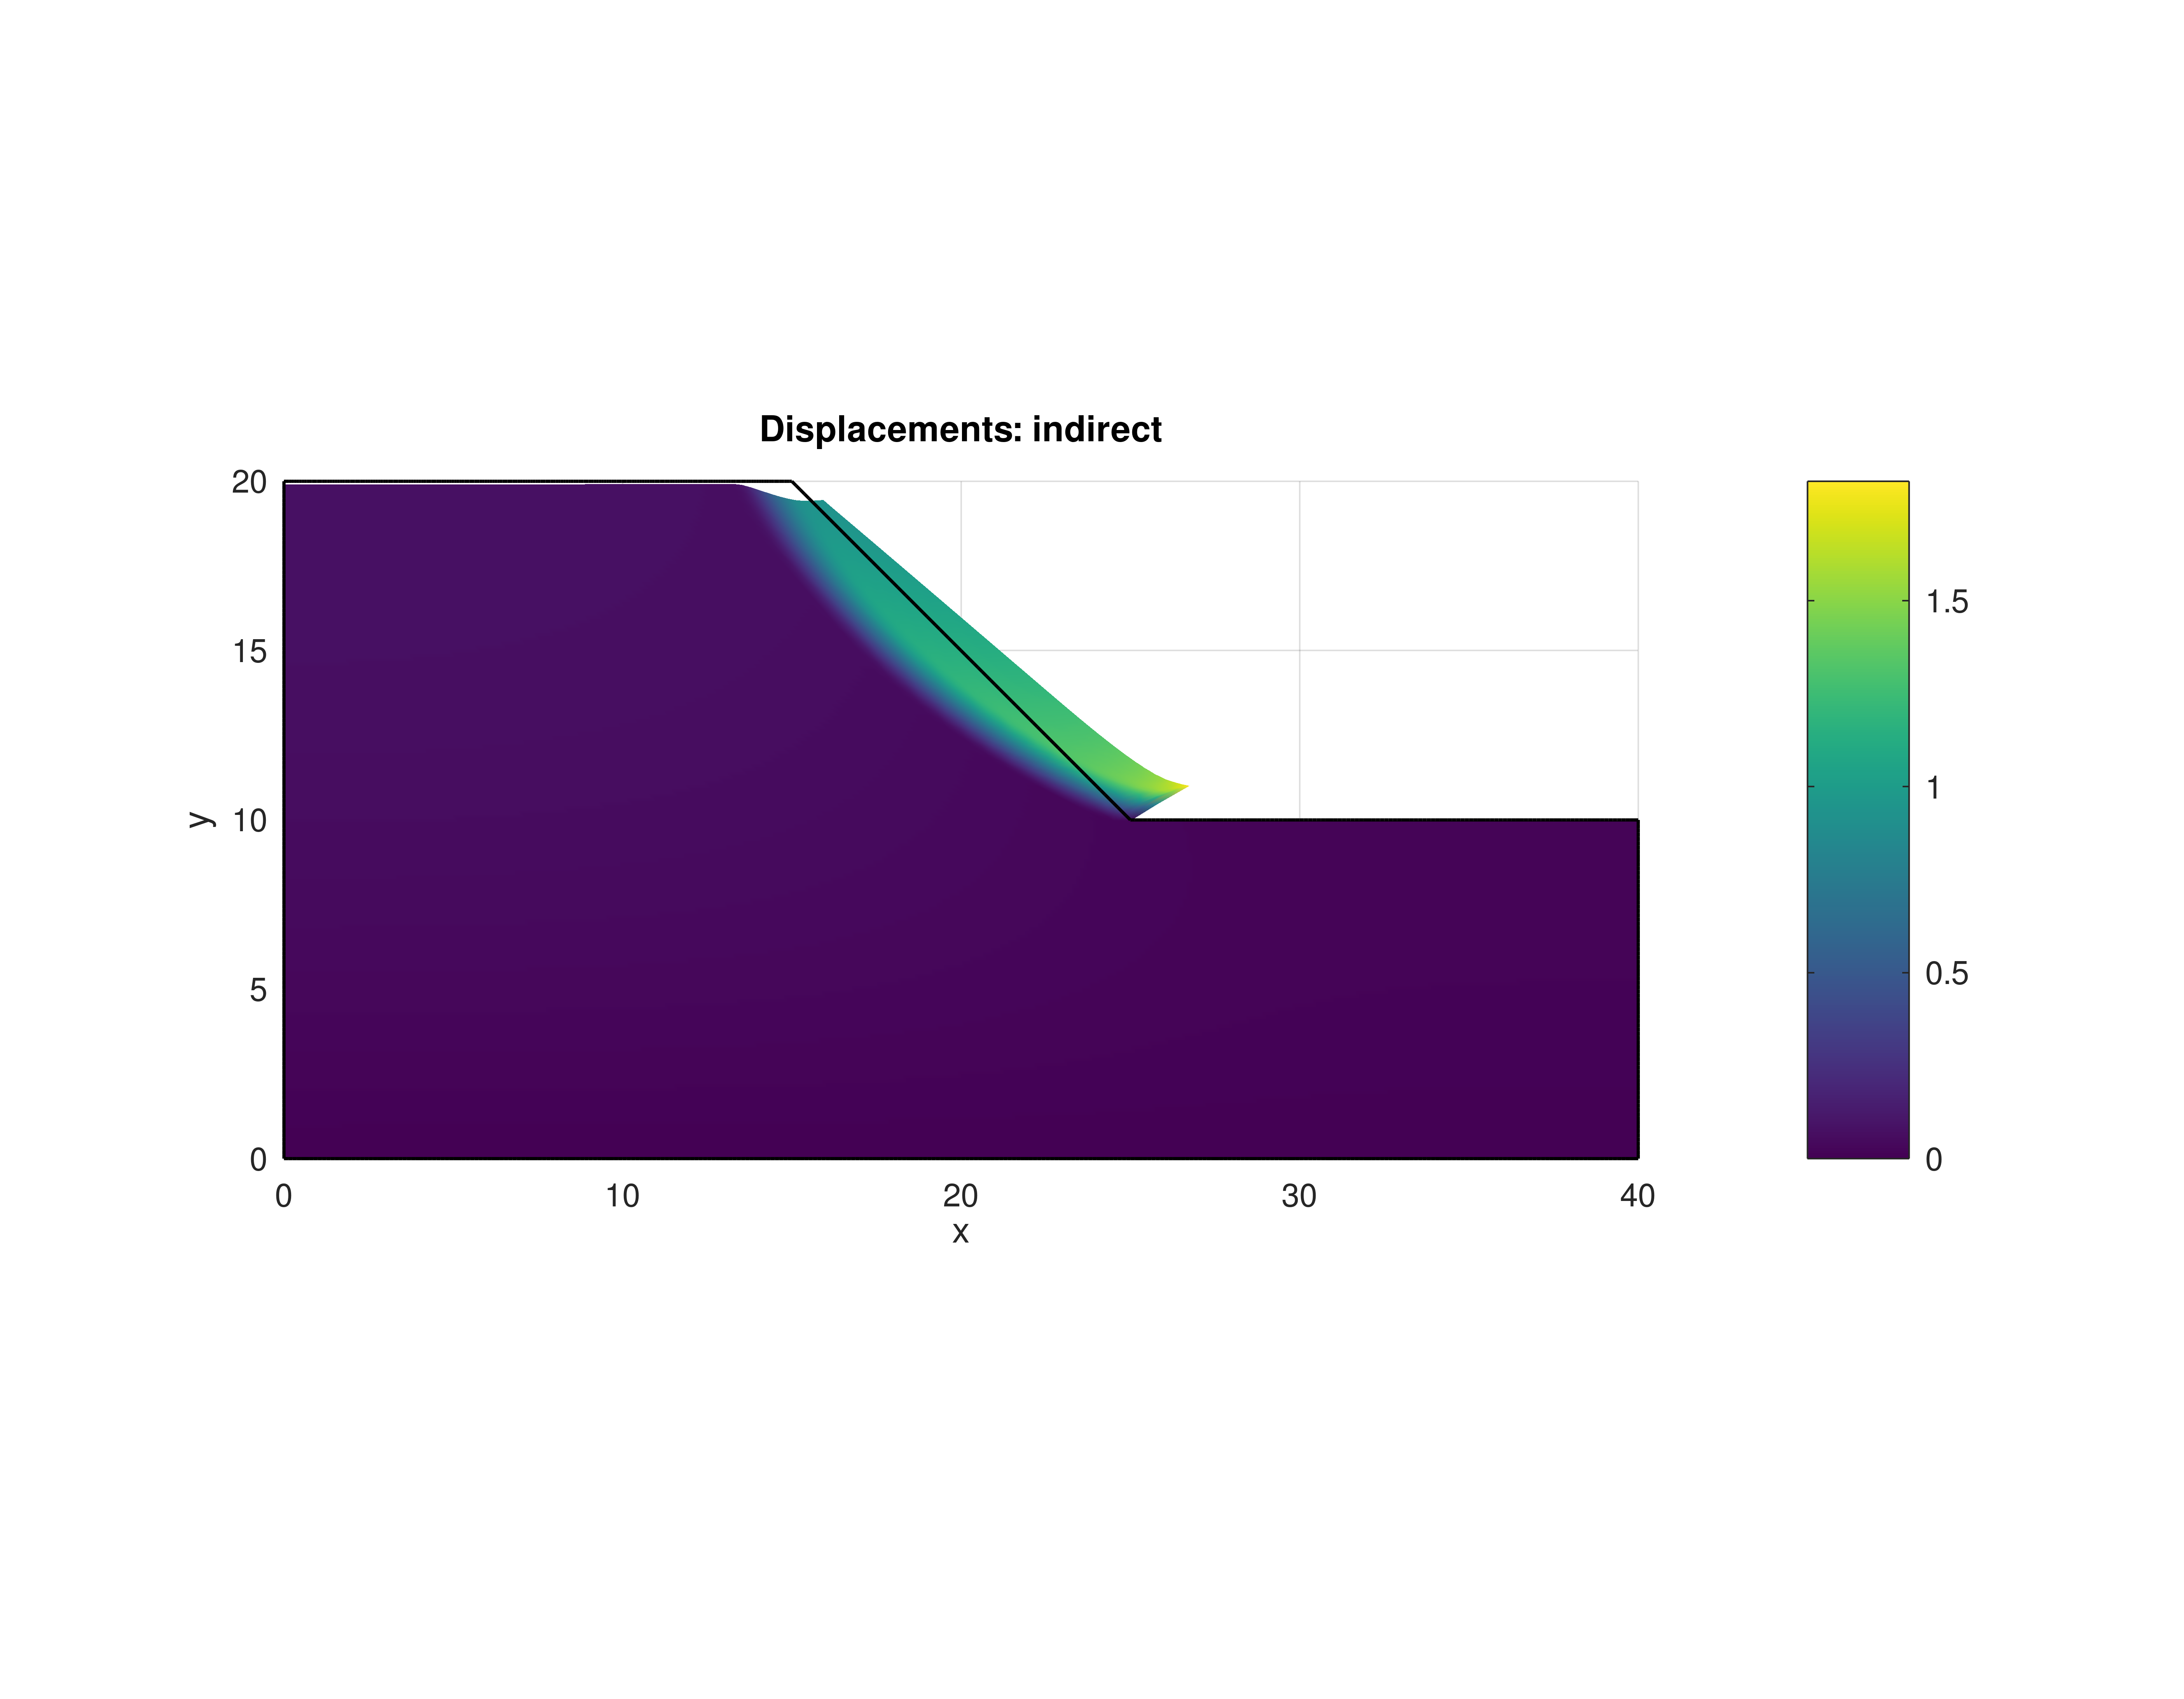

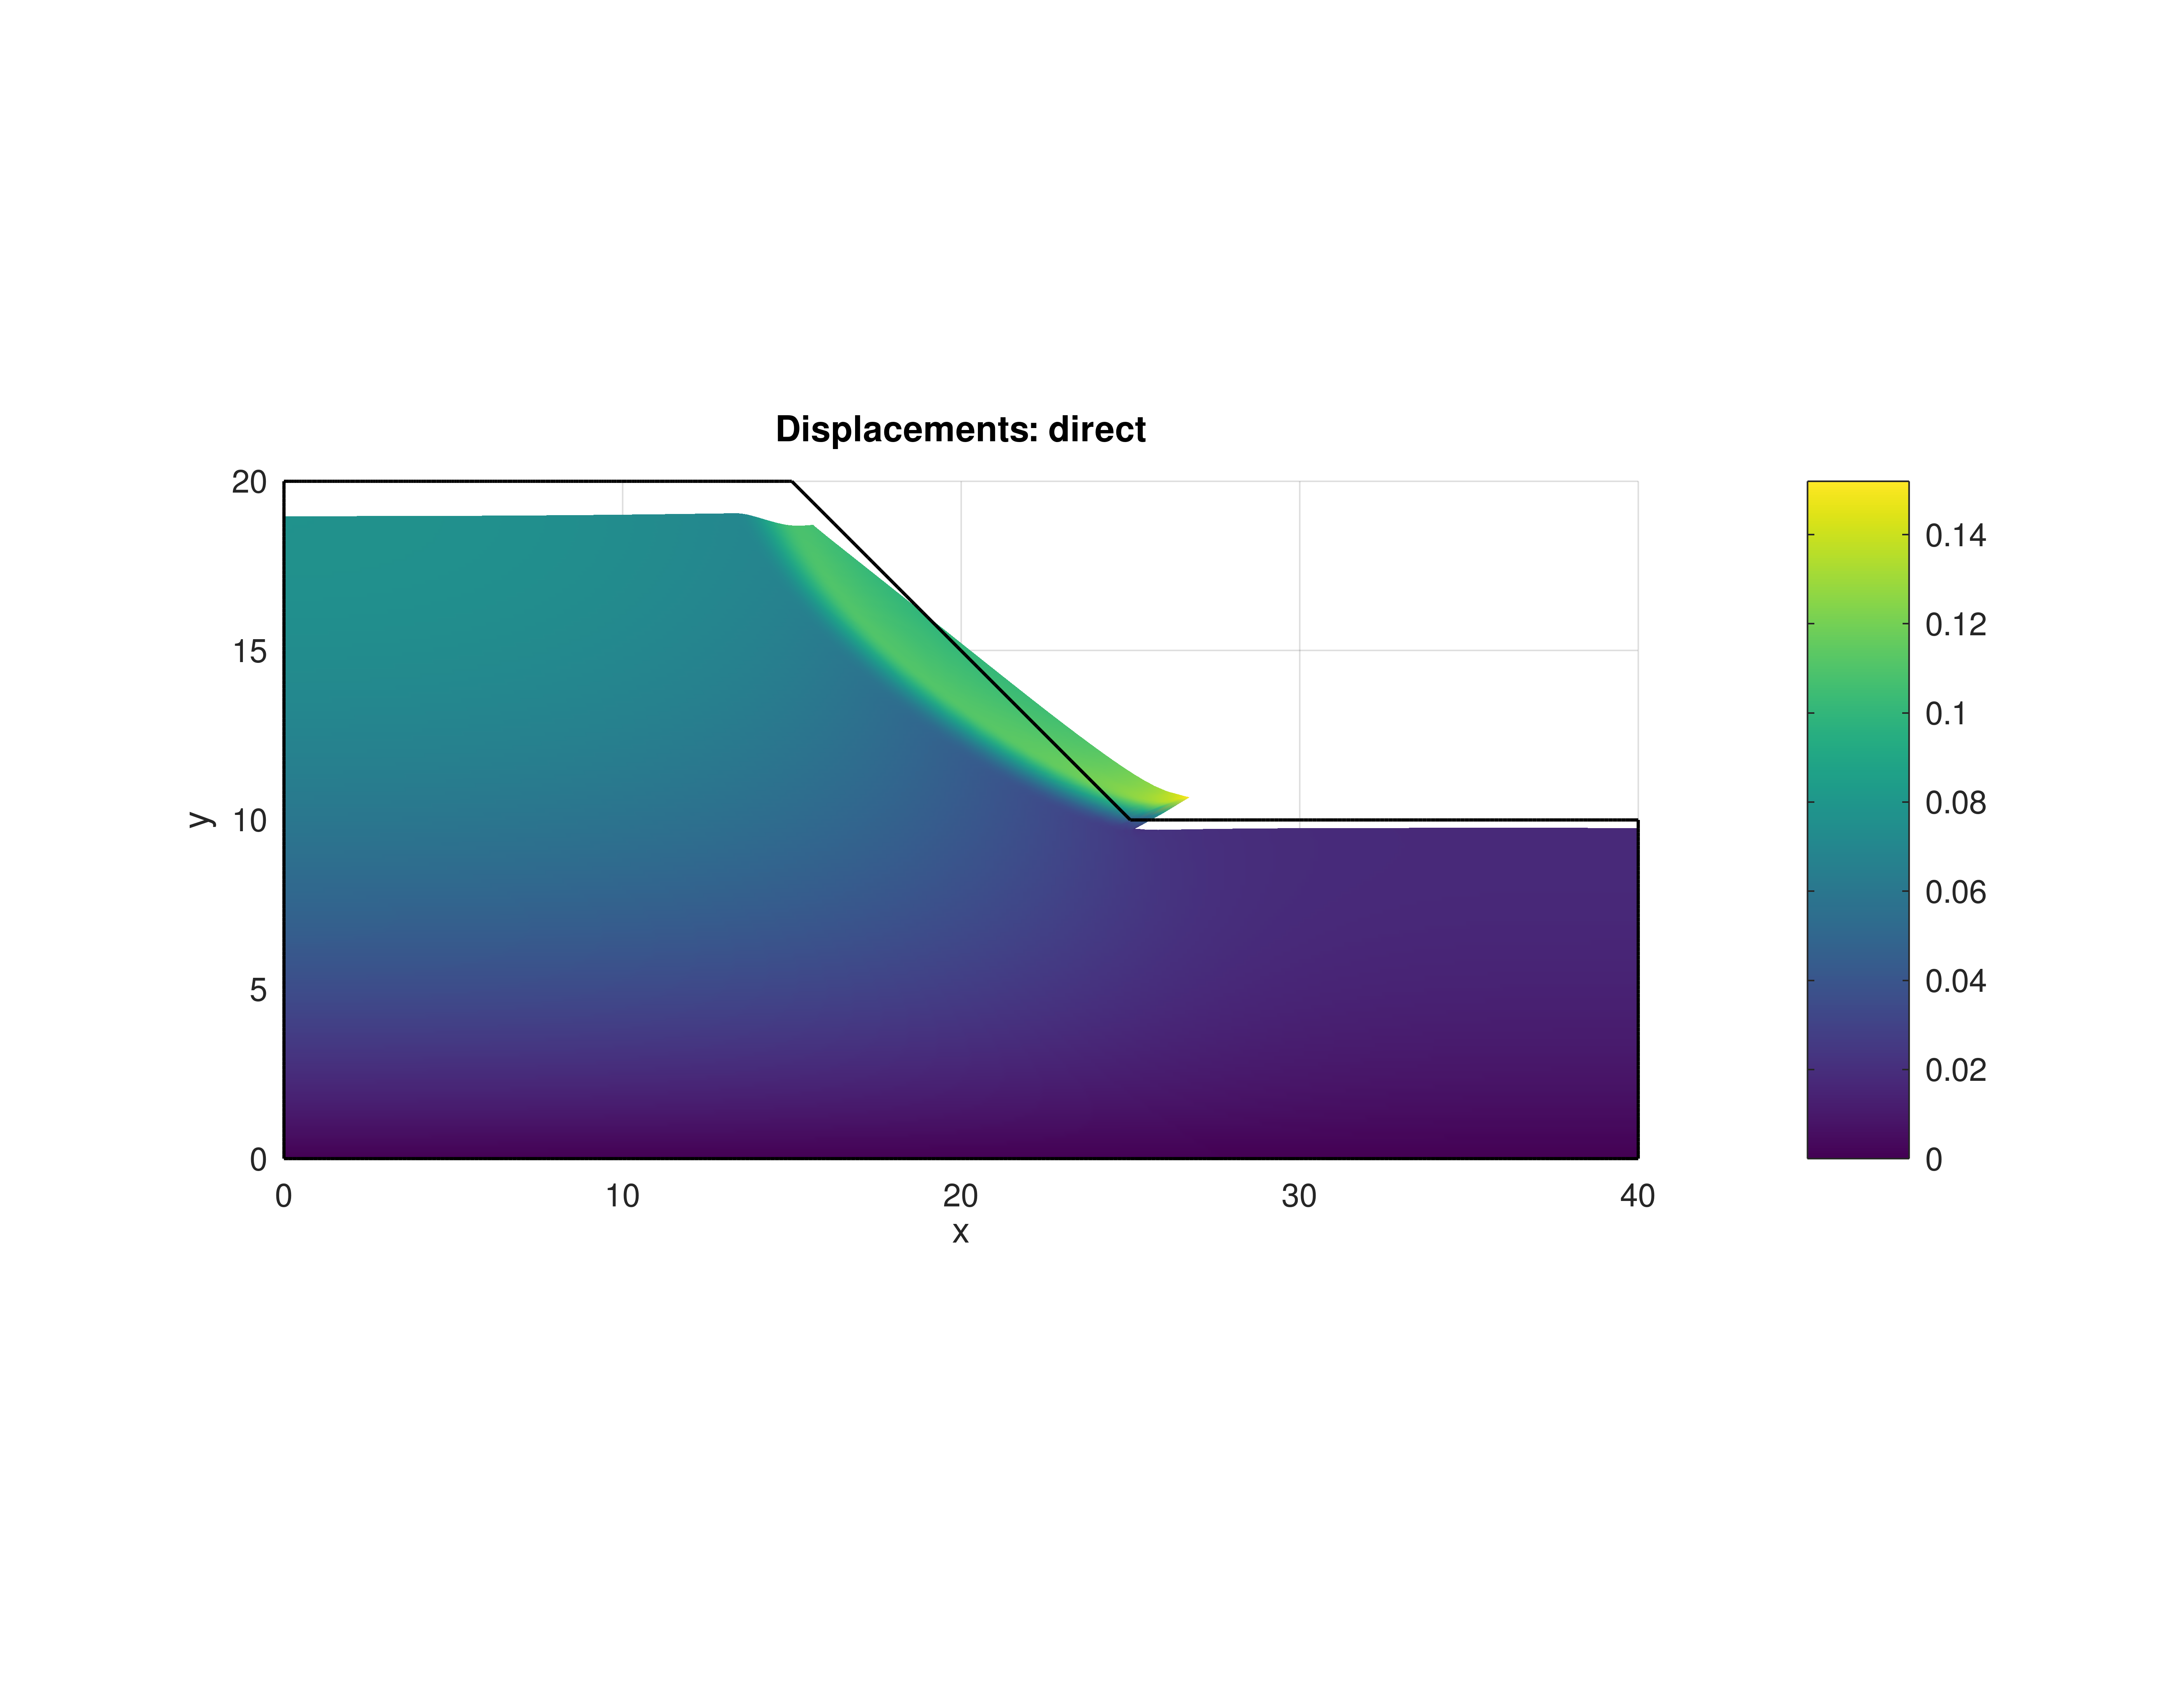

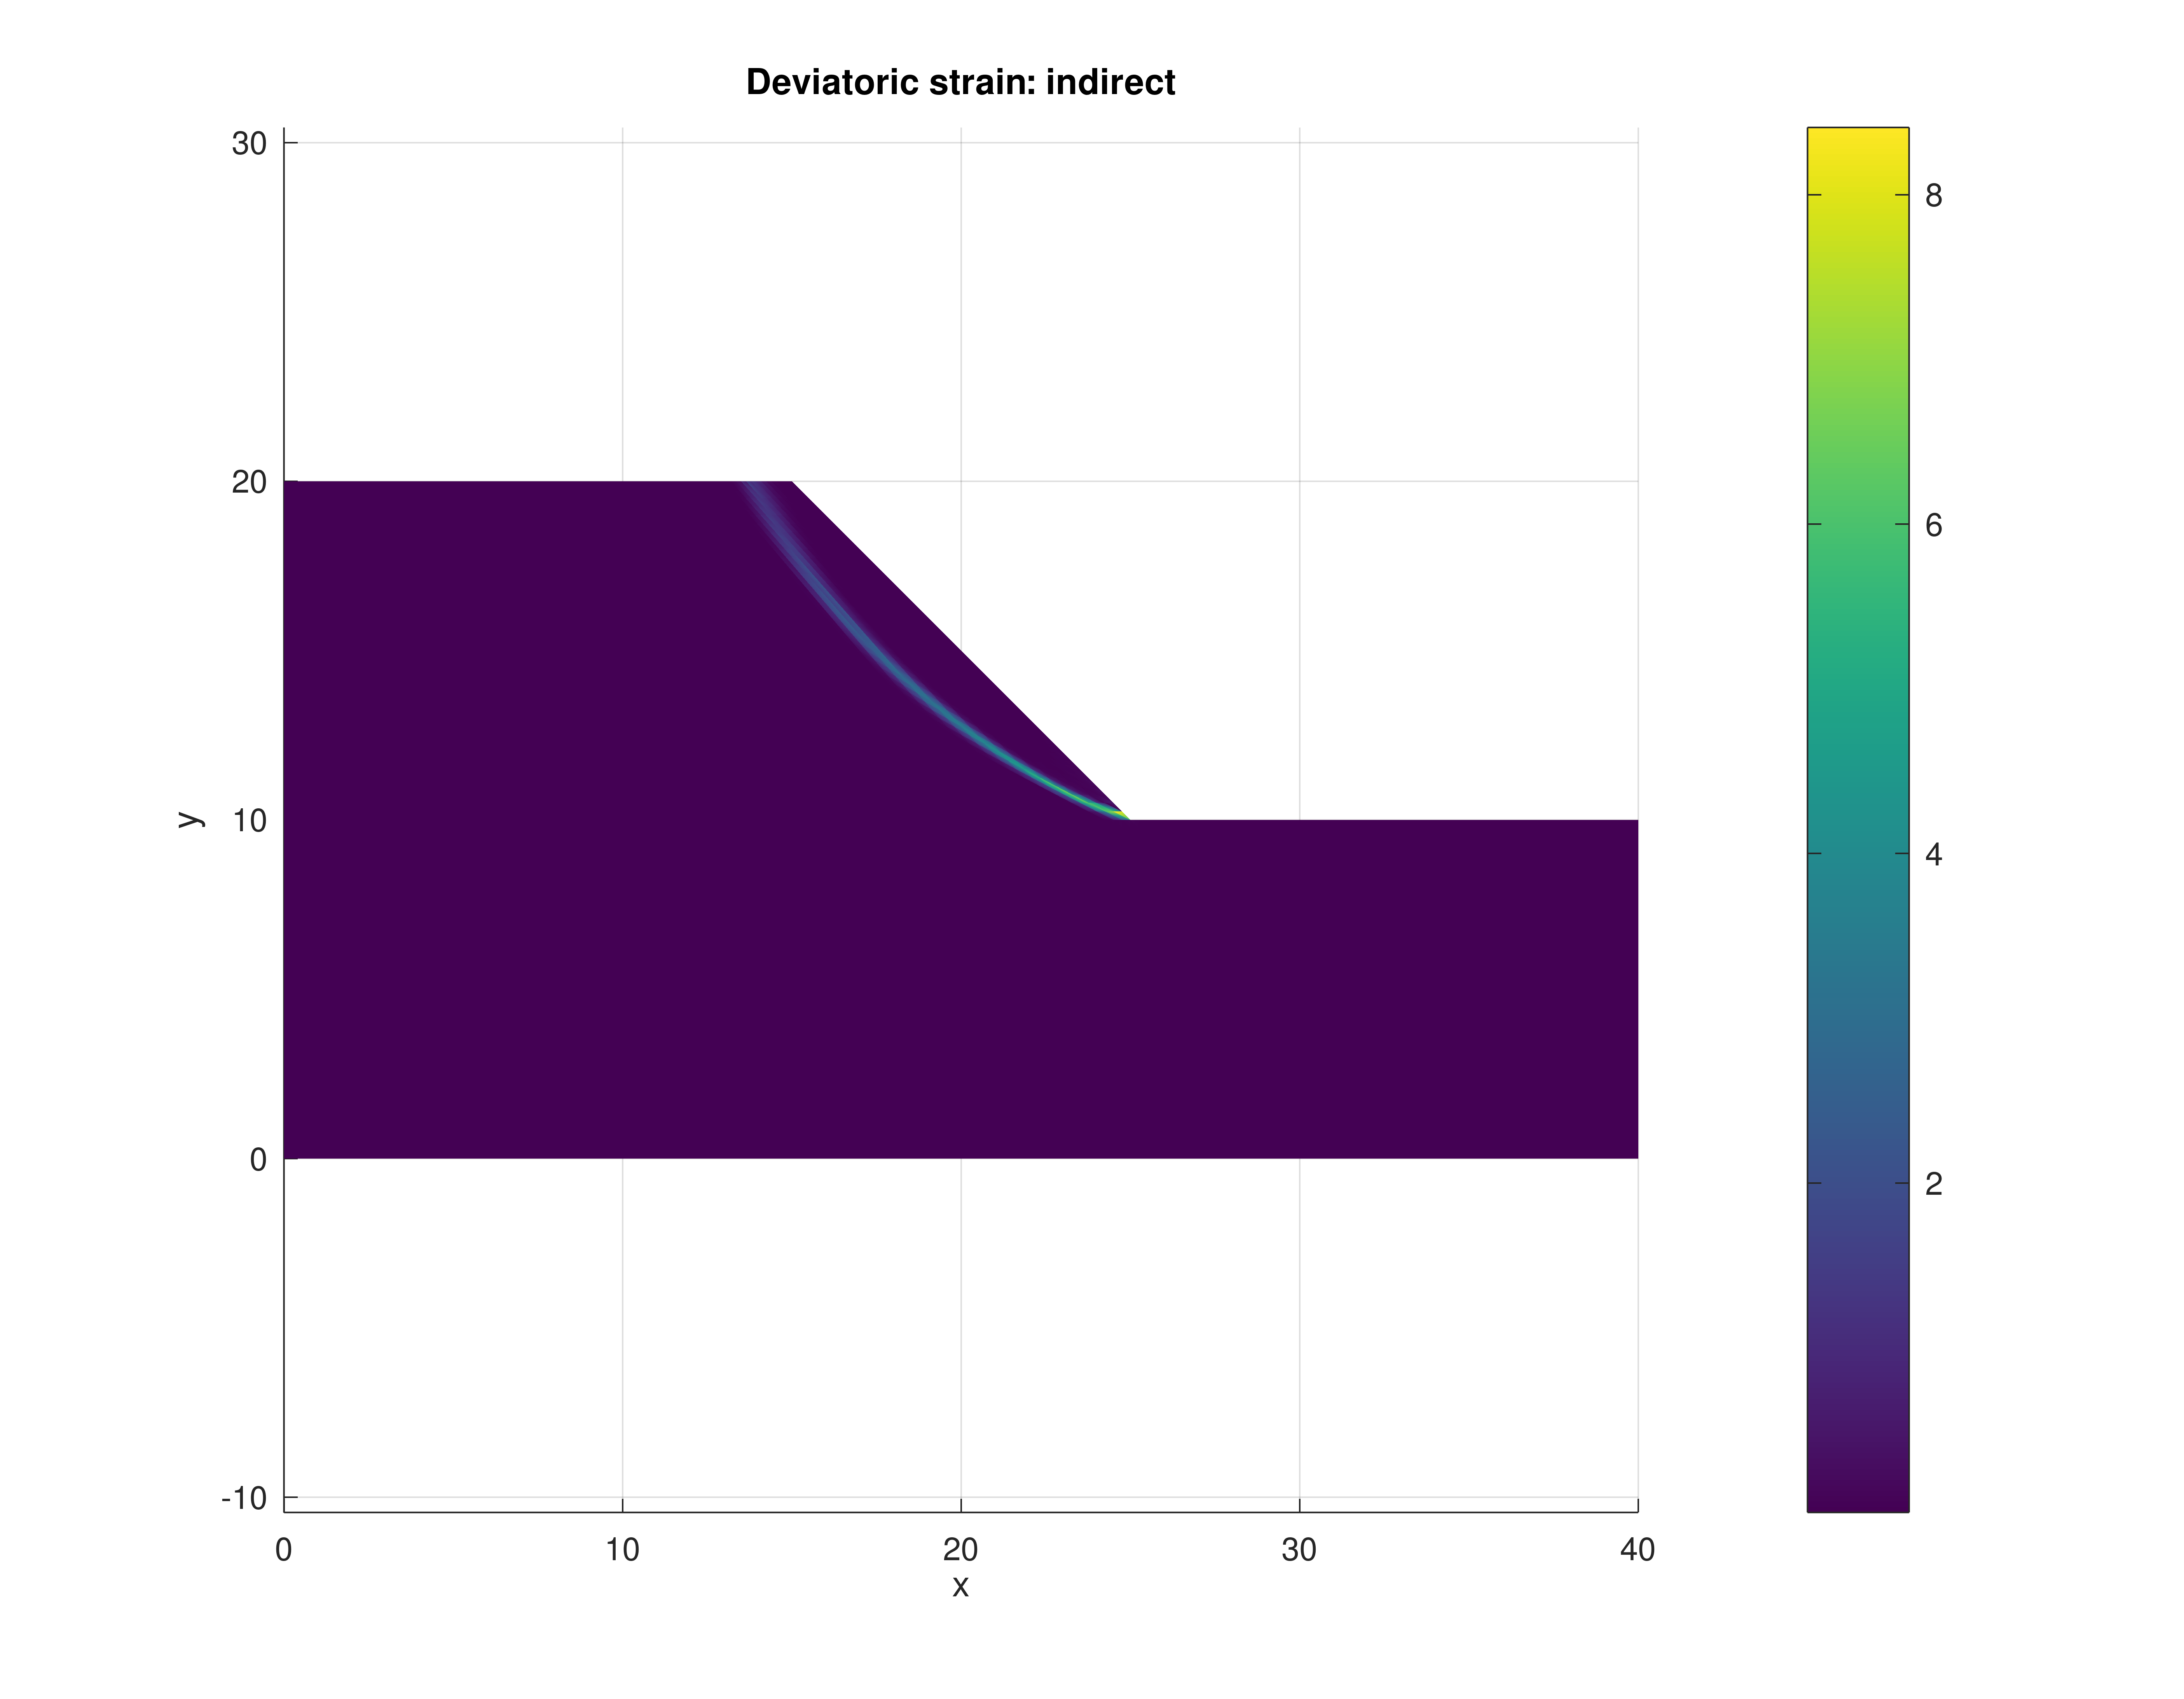

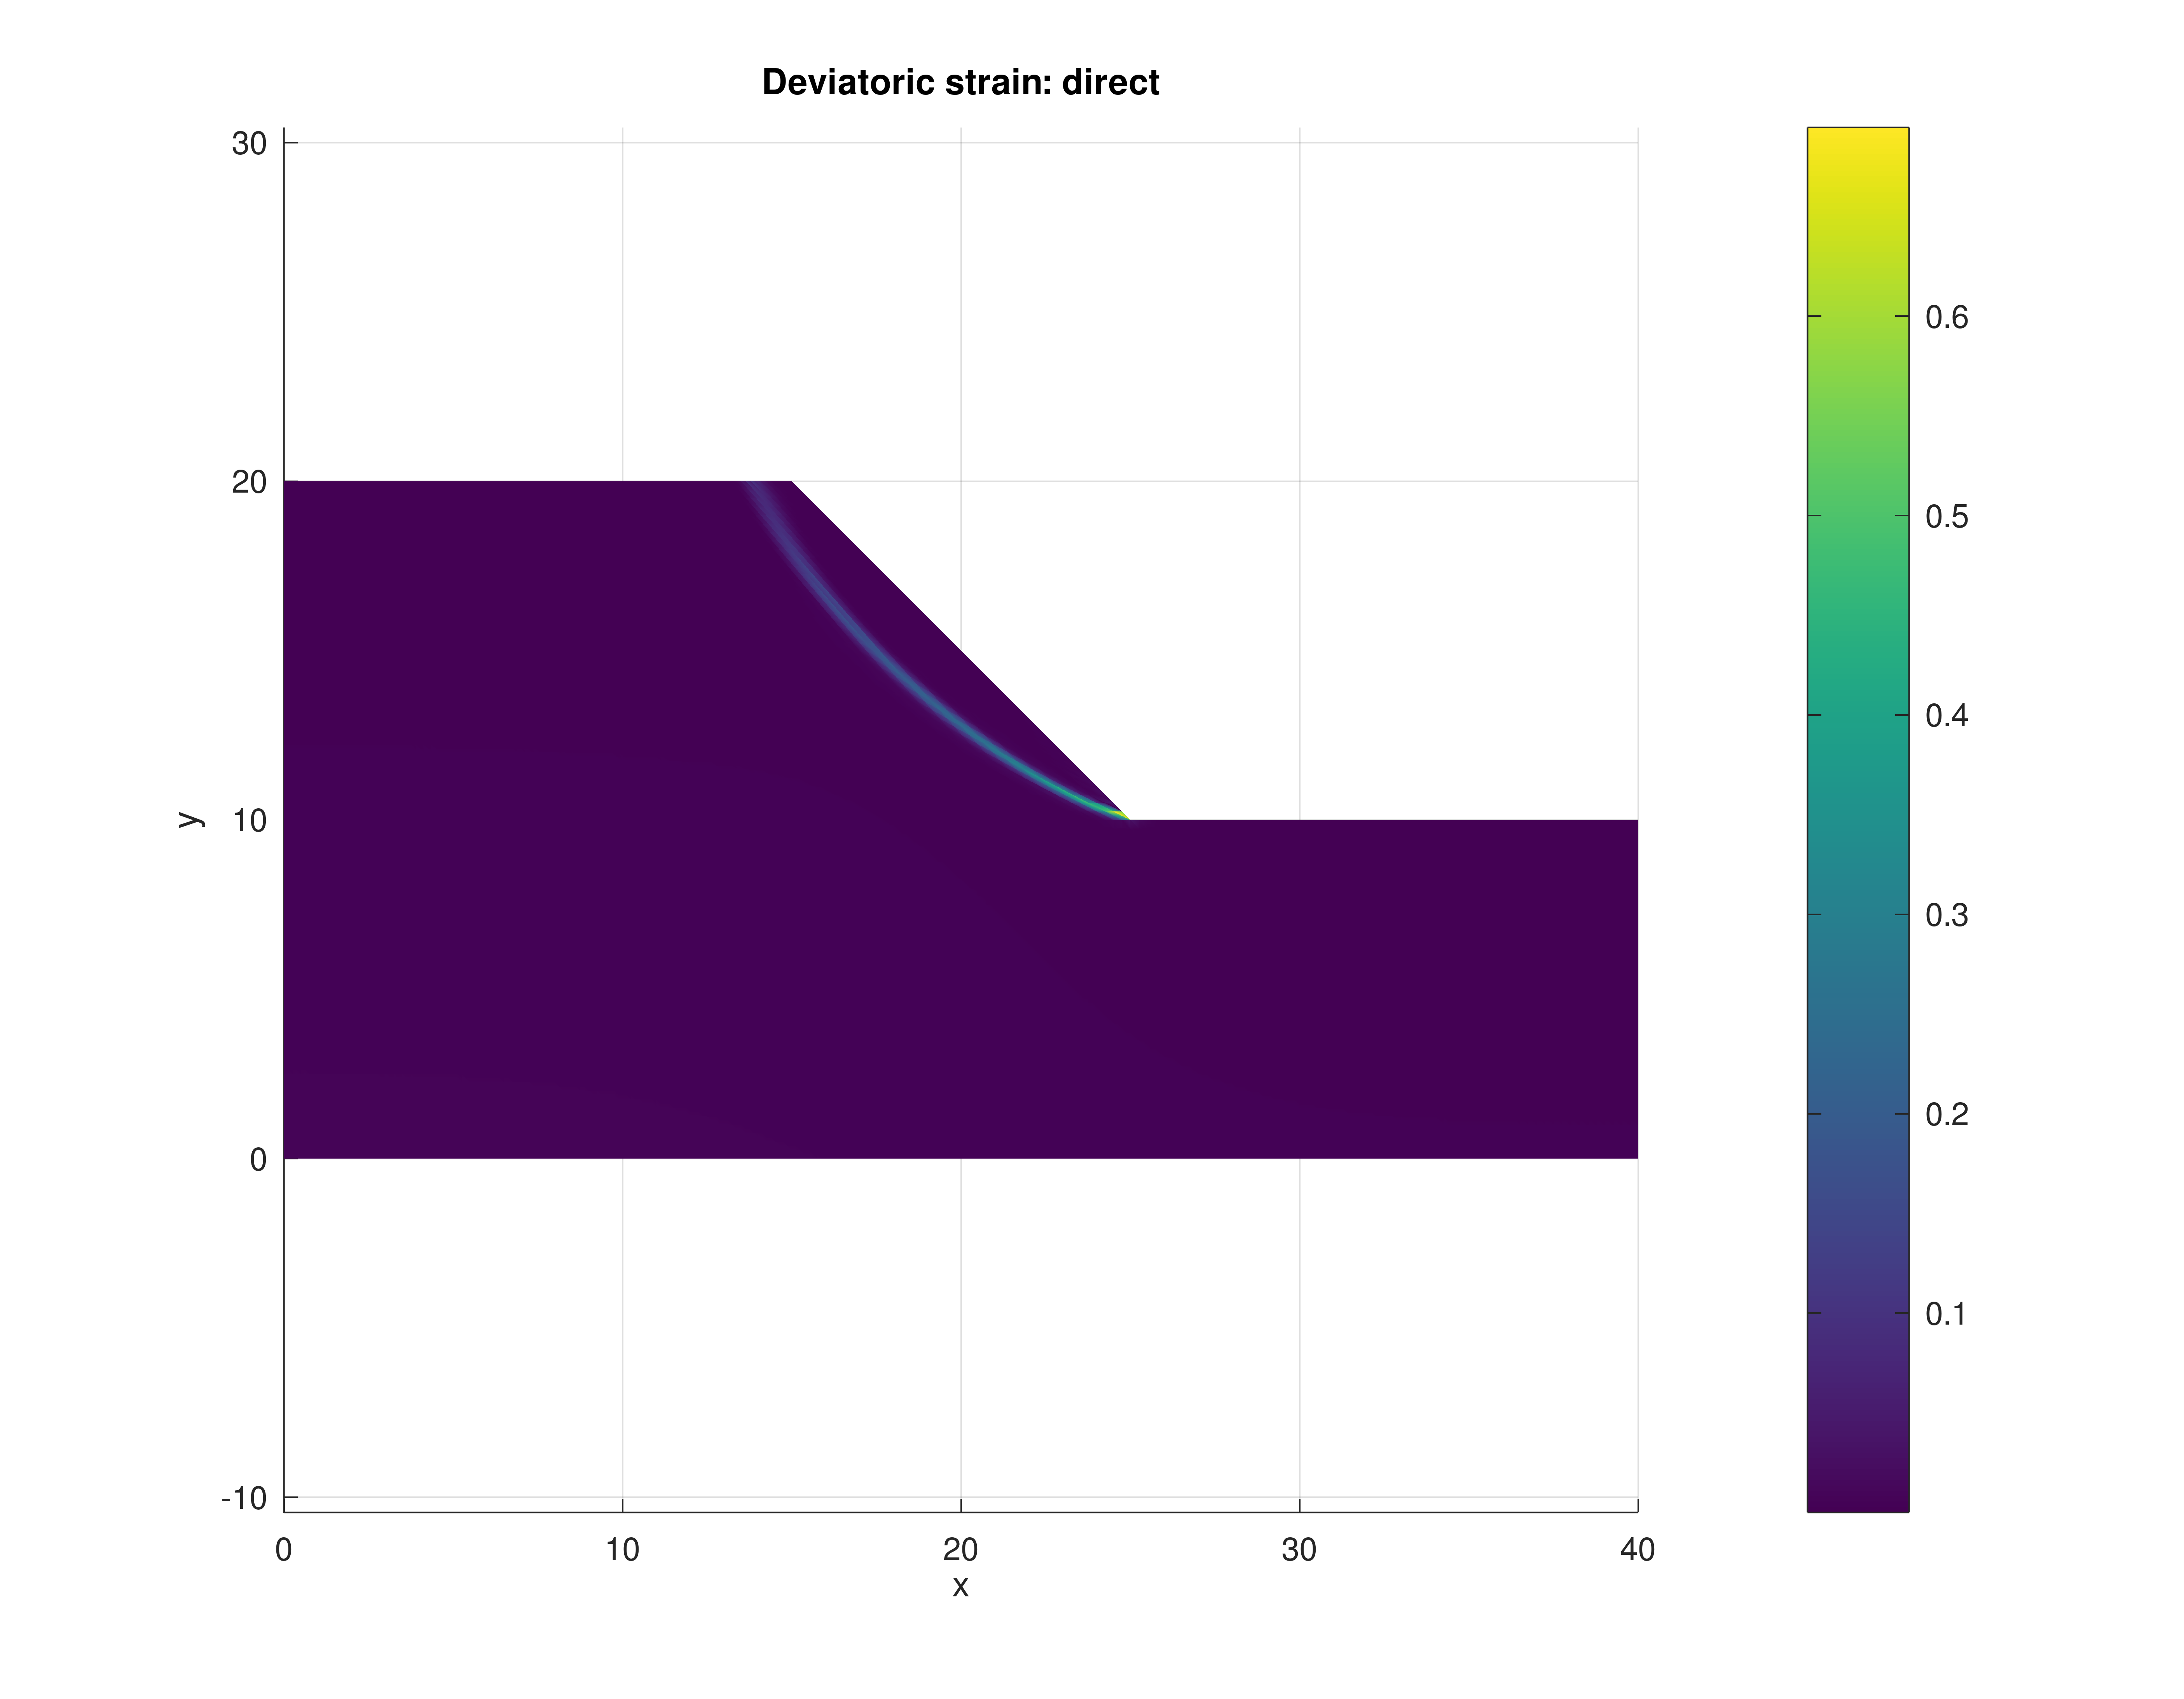

In [9]:
plotter = VIZ.SolutionPlotter(coord, elem, [], B, [], 'comsol');

if direct_on && exist('U2', 'var')
    plotter.add_solution('direct', U2, lambda_hist2, omega_hist2, Umax_hist2, struct( ...
        'title', 'Direct continuation method', ...
        'xlabel', 'Control variable - $\\omega$', ...
        'ylabel', 'strength reduction factor - $\\lambda$', ...
        'marker', '-o'));
end

if indirect_on && exist('U3', 'var')
    plotter.add_solution('indirect', U3, lambda_hist3, omega_hist3, Umax_hist3, struct( ...
        'title', 'Indirect continuation method', ...
        'xlabel', 'Control variable - $\\omega$', ...
        'ylabel', 'strength reduction factor - $\\lambda$', ...
        'marker', '-o'));
end

if plotter.n_solutions > 0
    plotter.plot_deviatoric_strain();
    plotter.plot_displacements();
    plotter.plot_convergence();
end

if direct_on && indirect_on && exist('lambda_hist2', 'var') && exist('lambda_hist3', 'var')
    lambda_direct_end = lambda_hist2(end);
    lambda_indirect_end = lambda_hist3(end);
    rel_gap = abs(lambda_direct_end - lambda_indirect_end) / max(1, abs(lambda_direct_end));
    disp(['Final lambda direct   = ', num2str(lambda_direct_end, '%.8f')]);
    disp(['Final lambda indirect = ', num2str(lambda_indirect_end, '%.8f')]);
    disp(['Relative direct/indirect gap = ', num2str(rel_gap, '%.4e')]);
end

if indirect_on && exist('lambda_hist3', 'var') && exist('omega_hist3', 'var')
    lambda_increasing = all(diff(lambda_hist3) >= -1e-10);
    omega_increasing = all(diff(omega_hist3) >= -1e-10);
    disp(['Monotonicity check (indirect): lambda=', num2str(lambda_increasing), ...
          ', omega=', num2str(omega_increasing)]);
end

disp('Notebook workflow completed.');
